# handwriting imagery of simple vowels: a, o, e, i, u, ü

In [1]:
import math
import copy
import gdown
import random
import scipy.io
import os
import mne
import shutil
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sn
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchsummary import summary
from torch.autograd import Variable
from torch.utils.data import DataLoader, TensorDataset, random_split, Subset
from sklearn.model_selection import KFold
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split
from mne.time_frequency import tfr_morlet  # FBCNet关键：导入Morlet小波变换

# 1、FBCNet 核心组件定义（约束层、激活层、时间聚合层）

In [2]:
# 1. 带权重约束的卷积层（FBCNet核心正则化）
class Conv2dWithConstraint(nn.Conv2d):
    def __init__(self, *args, doWeightNorm=True, max_norm=1, **kwargs):
        self.max_norm = max_norm
        self.doWeightNorm = doWeightNorm
        super(Conv2dWithConstraint, self).__init__(*args, **kwargs)

    def forward(self, x):
        if self.doWeightNorm:
            self.weight.data = torch.renorm(
                self.weight.data, p=2, dim=0, maxnorm=self.max_norm
            )
        return super(Conv2dWithConstraint, self).forward(x)

# 2. 带权重约束的线性层（FBCNet核心正则化）
class LinearWithConstraint(nn.Linear):
    def __init__(self, *args, doWeightNorm=True, max_norm=1, **kwargs):
        self.max_norm = max_norm
        self.doWeightNorm = doWeightNorm
        super(LinearWithConstraint, self).__init__(*args, **kwargs)

    def forward(self, x):
        if self.doWeightNorm:
            self.weight.data = torch.renorm(
                self.weight.data, p=2, dim=0, maxnorm=self.max_norm
            )
        return super(LinearWithConstraint, self).forward(x)

# 3. 时间聚合层（FBCNet支持多类统计聚合）
class VarLayer(nn.Module):
    def __init__(self, dim):
        super(VarLayer, self).__init__()
        self.dim = dim
    def forward(self, x):
        return x.var(dim=self.dim, keepdim=True)

class LogVarLayer(nn.Module):
    def __init__(self, dim):
        super(LogVarLayer, self).__init__()
        self.dim = dim
    def forward(self, x):
        return torch.log(torch.clamp(x.var(dim=self.dim, keepdim=True), 1e-6, 1e6))

class MeanLayer(nn.Module):
    def __init__(self, dim):
        super(MeanLayer, self).__init__()
        self.dim = dim
    def forward(self, x):
        return x.mean(dim=self.dim, keepdim=True)

# 时间聚合层字典（支持动态选择）
temporal_layer = {
    'VarLayer': VarLayer, 
    'LogVarLayer': LogVarLayer, 
    'MeanLayer': MeanLayer
}

# 4. Swish激活函数（FBCNet默认激活）
class swish(nn.Module):
    def __init__(self):
        super(swish, self).__init__()
    def forward(self, x):
        return x * torch.sigmoid(x)  

# 2、FBCNet 模型定义（适配手写想象数据）


In [3]:

# 单韵母模型（仅修改类别数nClass=6，其他参数与4秒笔画任务一致）
class FBCNetSingleVowelModel(nn.Module):
    def __init__(self, 
                 nChan=32,        # 通道数（与原笔画任务一致）
                 nTime=1000,      # 时间点（4秒×250Hz=1000，与原任务一致）
                 nClass=6,        # 单韵母类别数（6类：a, o, e, i, u, ü）
                 nBands=10,       # 滤波器组数量（复用原参数）
                 m=32,            # 每个频段的空间滤波器数量（复用原参数）
                 temporalLayer='LogVarLayer',  # 时间聚合方式（复用原配置）
                 strideFactor=4,  # 时间分块步长（复用原参数，1000/4=250块）
                 doWeightNorm=True):
        
        super().__init__()
        self.nBands = nBands
        self.m = m
        self.strideFactor = strideFactor

        # 1. 空间卷积块（与原模型完全一致，适配通道数和频段数）
        self.scb = nn.Sequential(
            Conv2dWithConstraint(
                in_channels=nBands,
                out_channels=m * nBands,
                kernel_size=(nChan, 1),  # 覆盖所有通道
                groups=nBands,           # 每个频段独立卷积
                max_norm=2,
                doWeightNorm=doWeightNorm,
                padding=0
            ),
            nn.BatchNorm2d(m * nBands),
            nn.SiLU()
        )

        # 2. 时间聚合层（复用原结构，适配1000时间点）
        self.temporalLayer = temporal_layer[temporalLayer](dim=3)

        # 3. 分类块（仅输出维度改为6类）
        self.lastLayer = nn.Sequential(
            LinearWithConstraint(
                in_features=m * nBands * strideFactor,  # 输入维度不变
                out_features=nClass,  # 输出6类
                max_norm=0.5,
                doWeightNorm=doWeightNorm
            ),
            nn.LogSoftmax(dim=1)
        )

    def forward(self, x):
        # 输入形状：(N, 1, C, T, nBands) → 与原笔画数据格式一致
        x = x.permute((0, 4, 2, 3, 1)).squeeze(-1)  # 转换为(N, nBands, C, T)
        
        # 空间滤波
        x = self.scb(x)  # (N, m×nBands, 1, T)
        
        # 时间分块（适配1000时间点，补零确保可被4整除）
        pad_length = x.shape[3] % self.strideFactor
        if pad_length != 0:
            x = F.pad(x, (0, pad_length))
        x = x.reshape([*x.shape[0:2], self.strideFactor, int(x.shape[3]/self.strideFactor)])
        
        # 时间聚合
        x = self.temporalLayer(x)  # (N, m×nBands, strideFactor, 1)
        
        # 分类
        x = torch.flatten(x, start_dim=1)
        x = self.lastLayer(x)  # (N, 6) → 6类单韵母
        
        return x

#  3、数据预处理（添加 FBCNet 多频段分解）

#  3.1 定义滤波器组（适配手写想象 1-40Hz 有效范围）

In [4]:
# FBCNet滤波器组：10个频段（含1-4Hz低频段，后续4Hz带宽）
freq_bands = [
    [1, 4], # 你关键的低频段（手写想象有效）[1, 4],  
    [4, 8],    # Theta
    [8, 12],   # Mu（运动想象核心频段）
    [12, 16],  # Low Beta
    [16, 20],  # Beta
    [20, 24],  # Beta
    [24, 28],  # High Beta
    [28, 32],  # Low Gamma
    [32, 36],  # Gamma
    [36, 40]   # Gamma
]
nBands = len(freq_bands)  # 频段数：10
sfreq_target = 250        # 目标采样率（降采样后）

#  3.2 Session1（T.bdf）预处理（训练集）

In [5]:
# 路径配置
raw_data_folder = r'F:\Hand_Writing_Imagery_Pinyin_Data\Event_&_ID' # 原始的数据路径：文件夹包含所有session的数据和事件Event
cleaned_data_folder = r'F:\Hand_Writing_Imagery_Pinyin_Data\First_Session'  #  保存 _T的数据 即session1的数据降被作为训练集
os.makedirs(cleaned_data_folder, exist_ok=True)

# 1. BDF转FIF（带滤波：仅陷波50Hz，不做高通1Hz，保留低频）
files = os.listdir(raw_data_folder)
filtered_files = [file for file in files if file.endswith('T.bdf')]  # 训练集数据

for file in filtered_files:
    file_path = os.path.join(raw_data_folder, file)
    # 读取原始数据
    raw = mne.io.read_raw_bdf(file_path, preload=True)
    # 仅做陷波滤波（去除50Hz线噪声），不做1Hz高通（保留1-4Hz低频）
    raw.notch_filter(freqs=50)
    # 保存为FIF（后续生成Epochs）
    new_file_path = os.path.join(cleaned_data_folder, file[:-4] + '.fif')
    raw.save(new_file_path, overwrite=True)
    print(f"Session1 {file} 预处理完成，保存为 {new_file_path}")


# 2. 读取事件文件（T_Event.txt）
events_folder = raw_data_folder
filtered_event_files = [f for f in os.listdir(events_folder) if f.endswith('T_Event.txt')]
subject_events = {}

for file in filtered_event_files:
    file_path = os.path.join(events_folder, file)
    events = []
    with open(file_path, 'r') as f:
        for line in f:
            sample, event_type = map(int, line.split())
            events.append([sample, 0, event_type])  # MNE事件格式：[样本点, 0, 事件类型]
    subject_events[os.path.splitext(file)[0]] = np.array(events)

Extracting EDF parameters from F:\Hand_Writing_Imagery_Pinyin_Data\Event_&_ID\A01T.bdf...
BDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 4003999  =      0.000 ...  4003.999 secs...
Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 49 - 51 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 49.38
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 49.12 Hz)
- Upper passband edge: 50.62 Hz
- Upper transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 50.88 Hz)
- Filter length: 6601 samples (6.601 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    1.8s


Overwriting existing file.
Writing F:\Hand_Writing_Imagery_Pinyin_Data\First_Session\A01T.fif


C:\Users\fan\AppData\Local\Temp\ipykernel_21172\2773080295.py:18: RuntimeWarning: This filename (F:\Hand_Writing_Imagery_Pinyin_Data\First_Session\A01T.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw.save(new_file_path, overwrite=True)


Closing F:\Hand_Writing_Imagery_Pinyin_Data\First_Session\A01T.fif
[done]
Session1 A01T.bdf 预处理完成，保存为 F:\Hand_Writing_Imagery_Pinyin_Data\First_Session\A01T.fif
Extracting EDF parameters from F:\Hand_Writing_Imagery_Pinyin_Data\Event_&_ID\A02T.bdf...
BDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 3771999  =      0.000 ...  3771.999 secs...
Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 49 - 51 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 49.38
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 49.12 Hz)
- Upper passband edge: 50.62 Hz
- Upper transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 50.88 Hz)
- Filter length: 6601 samples (6.601 s)



...

Closing F:\Hand_Writing_Imagery_Pinyin_Data\First_Session\A25T.fif
[done]
Session1 A25T.bdf 预处理完成，保存为 F:\Hand_Writing_Imagery_Pinyin_Data\First_Session\A25T.fif
Extracting EDF parameters from F:\Hand_Writing_Imagery_Pinyin_Data\Event_&_ID\A26T.bdf...
BDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 4048999  =      0.000 ...  4048.999 secs...
Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 49 - 51 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 49.38
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 49.12 Hz)
- Upper passband edge: 50.62 Hz
- Upper transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 50.88 Hz)
- Filter length: 6601 samples (6.601 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    1.7s


Overwriting existing file.
Writing F:\Hand_Writing_Imagery_Pinyin_Data\First_Session\A26T.fif


C:\Users\fan\AppData\Local\Temp\ipykernel_21172\2773080295.py:18: RuntimeWarning: This filename (F:\Hand_Writing_Imagery_Pinyin_Data\First_Session\A26T.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw.save(new_file_path, overwrite=True)


Closing F:\Hand_Writing_Imagery_Pinyin_Data\First_Session\A26T.fif
[done]
Session1 A26T.bdf 预处理完成，保存为 F:\Hand_Writing_Imagery_Pinyin_Data\First_Session\A26T.fif


#  3.3 Session2（E.bdf）预处理（测试集）

In [6]:
cleaned_data_folder_E = r'F:\Hand_Writing_Imagery_Pinyin_Data\Second_Session'
os.makedirs(cleaned_data_folder_E, exist_ok=True)

# 1. BDF转FIF（仅陷波滤波，保留低频）
files_E = os.listdir(raw_data_folder)
filtered_files_E = [file for file in files_E if file.endswith('E.bdf')]  # 测试集数据

for file in filtered_files_E:
    file_path = os.path.join(raw_data_folder, file)
    raw = mne.io.read_raw_bdf(file_path, preload=True)
    raw.notch_filter(freqs=50)  # 仅去50Hz线噪声
    new_file_path = os.path.join(cleaned_data_folder_E, file[:-4] + '.fif')
    raw.save(new_file_path, overwrite=True)
    print(f"Session2 {file} 预处理完成，保存为 {new_file_path}")


# 2. 读取测试集事件文件（E_Event.txt）
filtered_event_files_E = [f for f in os.listdir(events_folder) if f.endswith('E_Event.txt')]
subject_events_E = {}

for file in filtered_event_files_E:
    file_path = os.path.join(events_folder, file)
    events = []
    with open(file_path, 'r') as f:
        for line in f:
            sample, event_type = map(int, line.split())
            events.append([sample, 0, event_type])
    subject_events_E[os.path.splitext(file)[0]] = np.array(events)


Extracting EDF parameters from F:\Hand_Writing_Imagery_Pinyin_Data\Event_&_ID\A01E.bdf...
BDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 3649999  =      0.000 ...  3649.999 secs...
Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 49 - 51 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 49.38
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 49.12 Hz)
- Upper passband edge: 50.62 Hz
- Upper transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 50.88 Hz)
- Filter length: 6601 samples (6.601 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    1.6s


Overwriting existing file.
Writing F:\Hand_Writing_Imagery_Pinyin_Data\Second_Session\A01E.fif


C:\Users\fan\AppData\Local\Temp\ipykernel_21172\335843058.py:13: RuntimeWarning: This filename (F:\Hand_Writing_Imagery_Pinyin_Data\Second_Session\A01E.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw.save(new_file_path, overwrite=True)


Closing F:\Hand_Writing_Imagery_Pinyin_Data\Second_Session\A01E.fif
[done]
Session2 A01E.bdf 预处理完成，保存为 F:\Hand_Writing_Imagery_Pinyin_Data\Second_Session\A01E.fif
Extracting EDF parameters from F:\Hand_Writing_Imagery_Pinyin_Data\Event_&_ID\A02E.bdf...
BDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 4475999  =      0.000 ...  4475.999 secs...
Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 49 - 51 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 49.38
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 49.12 Hz)
- Upper passband edge: 50.62 Hz
- Upper transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 50.88 Hz)
- Filter length: 6601 samples (6.601 s)



...

Closing F:\Hand_Writing_Imagery_Pinyin_Data\Second_Session\A25E.fif
[done]
Session2 A25E.bdf 预处理完成，保存为 F:\Hand_Writing_Imagery_Pinyin_Data\Second_Session\A25E.fif
Extracting EDF parameters from F:\Hand_Writing_Imagery_Pinyin_Data\Event_&_ID\A26E.bdf...
BDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 3849999  =      0.000 ...  3849.999 secs...
Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 49 - 51 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 49.38
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 49.12 Hz)
- Upper passband edge: 50.62 Hz
- Upper transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 50.88 Hz)
- Filter length: 6601 samples (6.601 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    1.8s


Overwriting existing file.
Writing F:\Hand_Writing_Imagery_Pinyin_Data\Second_Session\A26E.fif


C:\Users\fan\AppData\Local\Temp\ipykernel_21172\335843058.py:13: RuntimeWarning: This filename (F:\Hand_Writing_Imagery_Pinyin_Data\Second_Session\A26E.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw.save(new_file_path, overwrite=True)


Closing F:\Hand_Writing_Imagery_Pinyin_Data\Second_Session\A26E.fif
[done]
Session2 A26E.bdf 预处理完成，保存为 F:\Hand_Writing_Imagery_Pinyin_Data\Second_Session\A26E.fif


#  生成训练数据集的多频段数据

In [15]:
import os
import mne
import numpy as np

# 3. 生成多频段Epochs数据（适配单韵母：6类，4秒）
cleaned_data_folder = r'F:\Hand_Writing_Imagery_Pinyin_Data\First_Session'  # 单韵母数据路径
fif_files = ['A08T.fif']  # 单韵母被试数据（如A25T对应单韵母任务）
all_subjects_data_T = []  # 存储多频段数据：(N,C,T,nBands)
all_subjects_labels_T = []

# 假设subject_events已加载单韵母的事件字典（键为事件文件名，值为事件数组）
# subject_events = load_vowel_events()  # 确保包含单韵母的事件数据

for fif_file in fif_files:
    fif_path = os.path.join(cleaned_data_folder, fif_file)
    raw = mne.io.read_raw_fif(fif_path, preload=True)
    
    # 删除Status通道（与原代码一致）
    if "Status" in raw.info["ch_names"]:
        raw.drop_channels(["Status"])
    sfreq = raw.info["sfreq"]
    sfreq_target = 250  # 降采样目标频率（250Hz，4秒→1000点）

    # 匹配单韵母事件文件（关键修改：适配单韵母事件文件命名）
    subject_event_key = os.path.splitext(fif_file)[0] + '_Event'  # 例如A25T_Event
    events = subject_events[subject_event_key]  # 读取单韵母事件

    # 生成Epochs（4秒窗口：0-4s，与原代码一致）
    tmin, tmax = 0, 4 - 1/sfreq
    # 单韵母事件ID（6类，关键修改：对应6个单韵母）
    event_id = {'1':1, '2':2, '3':3, '4':4, '5':5, '6':6}  # 1-6对应a/o/e/i/u/ü
    epochs = mne.Epochs(
        raw, events, event_id, tmin, tmax,
        reject=None, baseline=None, preload=True
    )

    # 降采样到250Hz（确保时间点为1000，4秒×250Hz）
    epochs_resampled = epochs.copy().resample(sfreq_target, npad="auto")
    n_epochs, n_chan, n_time = epochs_resampled.get_data().shape
    labels = epochs_resampled.events[:, -1]  # 提取标签（1-6）

    # -------------------------- 多频段分解（带通滤波，无需修改） --------------------------
    # 频段列表（复用原10个频段，单韵母脑电特征适用）
    freq_bands = [[1, 4], [4,8], [8,12], [12,16], [16,20],
                  [20,24], [24,28], [28,32], [32,36], [36,40]]
    nBands = len(freq_bands)

    # 初始化多频段数据容器：(n_epochs, n_chan, n_time, nBands)
    fb_data = np.zeros((n_epochs, n_chan, n_time, nBands))

    # 遍历每个频段进行带通滤波
    for band_idx, F in enumerate(freq_bands):
        l_freq, h_freq = F[0], F[1]
        epochs_band = epochs_resampled.copy().filter(
            l_freq=l_freq, h_freq=h_freq,
            method='iir', iir_params={'order': 4, 'ftype': 'butter'},
            verbose=False
        )
        fb_data[:, :, :, band_idx] = epochs_band.get_data()

    # 汇总数据
    all_subjects_data_T.append(fb_data)
    all_subjects_labels_T.append(labels)
    print(f"Session1 {fif_file} 多频段处理完成，数据形状：{fb_data.shape}，标签形状：{labels.shape}")  

Opening raw data file F:\Hand_Writing_Imagery_Pinyin_Data\First_Session\A08T.fif...


C:\Users\fan\AppData\Local\Temp\ipykernel_21172\3515194741.py:16: RuntimeWarning: This filename (F:\Hand_Writing_Imagery_Pinyin_Data\First_Session\A08T.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw = mne.io.read_raw_fif(fif_path, preload=True)


Isotrak not found
    Range : 0 ... 3805999 =      0.000 ...  3805.999 secs
Ready.
Reading 0 ... 3805999  =      0.000 ...  3805.999 secs...
Not setting metadata
240 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 240 events and 4000 original time points ...
0 bad epochs dropped
Session1 A08T.fif 多频段处理完成，数据形状：(240, 32, 1000, 10)，标签形状：(240,)


#  生成测试数据集的多频段数据¶

In [16]:

# 3. 生成测试集多频段数据（适配单韵母：6类，与训练集流程完全统一）
cleaned_data_folder_E = r'F:\Hand_Writing_Imagery_Pinyin_Data\Second_Session'  # 单韵母测试集路径
fif_files_E = ['A08E.fif']  # 单韵母测试集被试数据（如A25E对应单韵母测试任务）
all_subjects_data_E = []  # 存储测试集多频段数据：(N,C,T,nBands)
all_subjects_labels_E = []
sfreq_target = 250  # 与训练集一致，降采样到250Hz

# 假设subject_events_E已加载单韵母测试集的事件字典
# subject_events_E = load_vowel_test_events()  # 确保包含单韵母测试事件

for fif_file in fif_files_E:
    fif_path = os.path.join(cleaned_data_folder_E, fif_file)
    raw = mne.io.read_raw_fif(fif_path, preload=True)
    
    # 删除Status通道（与训练集一致）
    if "Status" in raw.info["ch_names"]:
        raw.drop_channels(["Status"])
    sfreq = raw.info["sfreq"]

    # 匹配单韵母测试集事件文件（关键修改：适配测试集事件命名）
    subject_event_key = os.path.splitext(fif_file)[0] + '_Event'  # 例如A25E_Event
    events = subject_events_E[subject_event_key]  # 读取单韵母测试事件

    # 生成Epochs（4秒窗口，与训练集一致）
    tmin, tmax = 0, 4 - 1/sfreq
    # 单韵母测试集事件ID（6类，关键修改：与训练集类别数一致）
    event_id = {'1':1, '2':2, '3':3, '4':4, '5':5, '6':6}  # 对应6个单韵母
    epochs = mne.Epochs(
        raw, events, event_id, tmin, tmax,
        reject=None, baseline=None, preload=True
    )

    # 降采样到250Hz（确保时间点为1000，与训练集一致）
    epochs_resampled = epochs.copy().resample(sfreq_target, npad="auto")
    n_epochs, n_chan, n_time = epochs_resampled.get_data().shape
    labels = epochs_resampled.events[:, -1]  # 测试集标签（1-6）

    # -------------------------- 多频段分解（与训练集完全一致，无需修改） --------------------------
    # 频段列表（与训练集严格一致，保证特征分布对齐）
    freq_bands = [[1, 4], [4,8], [8,12], [12,16], [16,20],
                  [20,24], [24,28], [28,32], [32,36], [36,40]]
    nBands = len(freq_bands)

    # 初始化多频段数据容器（格式与训练集完全相同）
    fb_data = np.zeros((n_epochs, n_chan, n_time, nBands))

    # 遍历频段（滤波参数与训练集一致，确保特征提取逻辑统一）
    for band_idx, F in enumerate(freq_bands):
        l_freq, h_freq = F[0], F[1]
        epochs_band = epochs_resampled.copy().filter(
            l_freq=l_freq, h_freq=h_freq,
            method='iir', iir_params={'order': 4, 'ftype': 'butter'},
            verbose=False
        )
        fb_data[:, :, :, band_idx] = epochs_band.get_data()

    # 汇总测试集数据（格式与训练集一致，确保模型评估兼容）
    all_subjects_data_E.append(fb_data)
    all_subjects_labels_E.append(labels)
    print(f"Session2 {fif_file} 多频段处理完成，数据形状：{fb_data.shape}，标签形状：{labels.shape}")  

Opening raw data file F:\Hand_Writing_Imagery_Pinyin_Data\Second_Session\A08E.fif...


C:\Users\fan\AppData\Local\Temp\ipykernel_21172\2507097718.py:13: RuntimeWarning: This filename (F:\Hand_Writing_Imagery_Pinyin_Data\Second_Session\A08E.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw = mne.io.read_raw_fif(fif_path, preload=True)


Isotrak not found
    Range : 0 ... 4088999 =      0.000 ...  4088.999 secs
Ready.
Reading 0 ... 4088999  =      0.000 ...  4088.999 secs...
Not setting metadata
240 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 240 events and 4000 original time points ...
0 bad epochs dropped
Session2 A08E.fif 多频段处理完成，数据形状：(240, 32, 1000, 10)，标签形状：(240,)


In [17]:
# 设备配置（不变）
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"使用设备：{device}")

# 初始化归一化后的数据列表（用于存储多个被试的归一化结果）
normalized_all_subjects_data_T = []
normalized_all_subjects_labels_T = []
normalized_all_subjects_data_E = []
normalized_all_subjects_labels_E = []

# -------------------------- 训练集归一化（支持多被试，当前仅1个） --------------------------
# 循环：遍历所有被试（当前all_subjects_data_T长度=1，仅处理A01T）
for sub_idx in range(len(all_subjects_data_T)):
    data_T = all_subjects_data_T[sub_idx]  # 第sub_idx个被试的训练数据
    labels_T = all_subjects_labels_T[sub_idx]
    
    # 关键：每个被试用自身的均值/标准差归一化（避免被试间数据泄露）
    mean_T = np.mean(data_T)
    std_T = np.std(data_T)
    data_T_normalized = (data_T - mean_T) / std_T
    
    # 标签归一化
    labels_T_normalized = labels_T - np.min(labels_T)
    
    # 存储当前被试的归一化结果
    normalized_all_subjects_data_T.append(data_T_normalized)
    normalized_all_subjects_labels_T.append(labels_T_normalized)

# -------------------------- 测试集归一化（支持多被试，当前仅1个） --------------------------
for sub_idx in range(len(all_subjects_data_E)):
    data_E = all_subjects_data_E[sub_idx]
    labels_E = all_subjects_labels_E[sub_idx]
    
    mean_E = np.mean(data_E)
    std_E = np.std(data_E)
    data_E_normalized = (data_E - mean_E) / std_E
    
    labels_E_normalized = labels_E - np.min(labels_E)
    
    normalized_all_subjects_data_E.append(data_E_normalized)
    normalized_all_subjects_labels_E.append(labels_E_normalized)

# -------------------------- 选择目标被试（当前仅1个，索引=0） --------------------------
target_subject_idx = 0  # 选择第0个被试（即A01）
Train_data = normalized_all_subjects_data_T[target_subject_idx]
Train_label = normalized_all_subjects_labels_T[target_subject_idx]
Test_data = normalized_all_subjects_data_E[target_subject_idx]
Test_label = normalized_all_subjects_labels_E[target_subject_idx]

# -------------------------- 转换为Tensor（适配FBCNet输入，不变） --------------------------
X_train = torch.Tensor(Train_data).unsqueeze(1).to(device)
y_train = torch.LongTensor(Train_label).to(device)
X_test = torch.Tensor(Test_data).unsqueeze(1).to(device)
y_test = torch.LongTensor(Test_label).to(device)

# -------------------------- 创建TensorDataset（不变） --------------------------
train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

# -------------------------- 验证数据形状 --------------------------
print(f"训练集数据形状：{X_train.shape}")  # 期望：(N,1,32,1000,10)
print(f"训练集标签形状：{y_train.shape}")  # 期望：(N,)
print(f"测试集数据形状：{X_test.shape}")    # 期望：(M,1,32,1000,10)
print(f"测试集标签形状：{y_test.shape}")    # 期望：(M,)

使用设备：cuda
训练集数据形状：torch.Size([240, 1, 32, 1000, 10])
训练集标签形状：torch.Size([240])
测试集数据形状：torch.Size([240, 1, 32, 1000, 10])
测试集标签形状：torch.Size([240])


#  5、训练类修改（适配 FBCNet 损失函数）

In [18]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
import numpy as np
import random
import matplotlib  # 导入matplotlib主模块（关键修复）
import matplotlib.pyplot as plt
from matplotlib import font_manager
from sklearn.model_selection import KFold
import copy
import os
import glob  # 用于匹配缓存文件


class TrainModel:
    def __init__(self):
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.setup_fonts()

    def setup_fonts(self):
        """配置中文字体"""
        plt.rcParams["font.family"] = ["SimHei", "Microsoft YaHei"]
        plt.rcParams["axes.unicode_minus"] = False
        plt.rcParams["legend.fontsize"] = 10
        plt.rcParams["axes.titlesize"] = 12
        plt.rcParams["axes.labelsize"] = 10

        # 检查系统字体
        installed_fonts = []
        for font_path in font_manager.findSystemFonts():
            try:
                font_name = font_manager.FontProperties(fname=font_path).get_name()
                installed_fonts.append(font_name)
            except:
                continue
        missing_fonts = [f for f in ["SimHei", "Microsoft YaHei"] if f not in installed_fonts]
        if missing_fonts:
            print(f"警告：系统中未找到以下字体 {missing_fonts}，可能仍会显示乱码")
        else:
            print("字体配置成功")

    def clear_font_cache(self):
        """清除Matplotlib字体缓存（修复获取缓存目录的方法）"""
        try:
            # 正确方法：使用matplotlib主模块的get_cachedir()
            cache_dir = matplotlib.get_cachedir()
            # 匹配所有版本的字体缓存文件（如fontlist-v330.json、fontlist-v340.json等）
            font_cache_files = glob.glob(os.path.join(cache_dir, "fontlist-v*.json"))
            for file in font_cache_files:
                if os.path.exists(file):
                    os.remove(file)
                    print(f"已删除字体缓存文件：{file}")
        except Exception as e:
            print(f"清除字体缓存失败（不影响训练，仅可能影响中文显示）：{e}")

    def set_seed(self, seed):
        """设置随机种子"""
        torch.manual_seed(seed)
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)  
        np.random.seed(seed)
        random.seed(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

    def train_model(self, model_class, dataset, learning_rate=0.001, batch_size=64, 
                   epochs=500, n_splits=5, weight_decay=0.015, seed=42, selection_metric='accuracy'):
        self.clear_font_cache()  # 清除缓存
        self.set_seed(seed)
        kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
        all_fold_accuracies = []
        all_fold_losses = []
        best_model_state = None
        overall_best_val_metric = 0.0 if selection_metric == 'accuracy' else float('inf')

        for fold, (train_idx, val_idx) in enumerate(kf.split(dataset)):
            print(f"\n{'='*50}")
            print(f"第 {fold+1}/{n_splits} 折训练开始")
            print(f"{'='*50}")

            # 划分数据集
            train_subset = Subset(dataset, train_idx)
            val_subset = Subset(dataset, val_idx)
            train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True, pin_memory=False)
            val_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False, pin_memory=False)

            # 初始化模型
            model = model_class().to(self.device)
            criterion = nn.NLLLoss()
            optimizer = optim.Adam(
                model.parameters(),
                lr=learning_rate,
                weight_decay=weight_decay
            )

            best_val_accuracy_in_fold = 0.0
            best_val_loss_in_fold = float('inf')
            train_accuracies = []
            train_losses = []
            val_accuracies = []
            val_losses = []

            # 训练循环
            for epoch in range(epochs):
                model.train()
                running_loss = 0.0
                correct = 0
                total = 0

                # 训练阶段
                for inputs, labels in train_loader:
                    inputs = inputs.to(self.device)
                    labels = labels.to(self.device)

                    optimizer.zero_grad()
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                    loss.backward()
                    optimizer.step()

                    running_loss += loss.item() * inputs.size(0)
                    _, predicted = torch.max(outputs, 1)
                    total += labels.size(0)
                    correct += (predicted == labels).sum().item()

                epoch_loss = running_loss / len(train_loader.dataset)
                epoch_accuracy = correct / total
                train_losses.append(epoch_loss)
                train_accuracies.append(epoch_accuracy)
                print(f"Epoch [{epoch+1}/{epochs}] - 训练损失: {epoch_loss:.4f}, 训练准确率: {epoch_accuracy*100:.2f}%")

                # 验证阶段
                model.eval()
                val_loss = 0.0
                correct = 0
                total = 0
                with torch.no_grad():
                    for inputs, labels in val_loader:
                        inputs = inputs.to(self.device)
                        labels = labels.to(self.device)
                        outputs = model(inputs)
                        loss = criterion(outputs, labels)

                        val_loss += loss.item() * inputs.size(0)
                        _, predicted = torch.max(outputs, 1)
                        total += labels.size(0)
                        correct += (predicted == labels).sum().item()

                val_loss = val_loss / len(val_loader.dataset)
                val_accuracy = correct / total
                val_losses.append(val_loss)
                val_accuracies.append(val_accuracy)
                print(f"Epoch [{epoch+1}/{epochs}] - 验证损失: {val_loss:.4f}, 验证准确率: {val_accuracy*100:.2f}%")

                # 更新最佳指标
                if val_accuracy > best_val_accuracy_in_fold:
                    best_val_accuracy_in_fold = val_accuracy
                    best_val_loss_in_fold = val_loss
                    if val_accuracy > overall_best_val_metric:
                        overall_best_val_metric = val_accuracy
                        best_model_state = copy.deepcopy(model.state_dict())

            # 记录结果
            all_fold_accuracies.append(best_val_accuracy_in_fold)
            all_fold_losses.append(best_val_loss_in_fold)
            print(f"第 {fold+1} 折最佳验证准确率: {best_val_accuracy_in_fold*100:.2f}%")
            print(f"第 {fold+1} 折最佳验证损失: {best_val_loss_in_fold:.4f}")

            # 绘制曲线
            plt.figure(figsize=(12, 6))
            plt.subplot(1, 2, 1)
            plt.plot(range(1, epochs + 1), train_losses, label='训练损失', linewidth=2)
            plt.plot(range(1, epochs + 1), val_losses, label='验证损失', linewidth=2)
            plt.xlabel('迭代次数 (Epoch)')
            plt.ylabel('损失值 (Loss)')
            plt.title(f'第 {fold+1} 折 - 损失变化曲线', pad=10)
            plt.legend(loc='upper right')
            plt.grid(alpha=0.3)

            plt.subplot(1, 2, 2)
            plt.plot(range(1, epochs + 1), train_accuracies, label='训练准确率', linewidth=2)
            plt.plot(range(1, epochs + 1), val_accuracies, label='验证准确率', linewidth=2)
            plt.xlabel('迭代次数 (Epoch)')
            plt.ylabel('准确率 (Accuracy)')
            plt.title(f'第 {fold+1} 折 - 准确率变化曲线', pad=10)
            plt.legend(loc='lower right')
            plt.grid(alpha=0.3)

            plt.tight_layout()
            plt.show()

        # 输出交叉验证结果
        avg_val_acc = np.mean(all_fold_accuracies)
        avg_val_loss = np.mean(all_fold_losses)
        print(f"\n{'='*50}")
        print(f"五折交叉验证结果")
        print(f"平均验证准确率: {avg_val_acc*100:.2f}%")
        print(f"平均验证损失: {avg_val_loss:.4f}")
        print(f"全局最佳验证准确率: {overall_best_val_metric*100:.2f}%")
        print(f"{'='*50}")

        # 返回最佳模型
        final_model = model_class().to(self.device)
        final_model.load_state_dict(best_model_state)
        return final_model

#   评估类（无需修改，适配 FBCNet 输出）

In [19]:
from matplotlib import rcParams  

class EvalModel():
    def __init__(self, model):  
        self.model = model.to(device)
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # 测试模型（与你原代码一致，FBCNet输出适配）
    def test_model(self, test_dataset):  
        self.model.eval()
        correct = 0
        total = 0
        test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

        with torch.no_grad():  
            for inputs, labels in test_loader:
                inputs = inputs.to(self.device)
                labels = labels.to(self.device)
                outputs = self.model(inputs)  # FBCNet输出对数概率
                _, predicted = torch.max(outputs.data, 1)  # 取最大概率类别
                total += labels.size(0)
                correct += (predicted == labels).sum().item()  

        accuracy = (correct / total) * 100        
        print("/------------------------------/")
        print(f"测试集准确率: {accuracy:.2f}%")
        print("/------------------------------/")
        return accuracy

    # 绘制混淆矩阵（与你原代码一致）
    def plot_confusion_matrix(self, test_dataset, classes):
        rcParams['font.family'] = 'Times New Roman'
        self.model.eval()
        y_pred = []
        y_true = []
        test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs = inputs.to(self.device)
                labels = labels.to(self.device)
                outputs = self.model(inputs)
                _, predicted = torch.max(outputs.data, 1)
                y_pred.append(predicted.item())
                y_true.append(labels.item())
        
        # 计算混淆矩阵（归一化到0-1）
        cf_matrix = confusion_matrix(y_true, y_pred)
        row_sums = cf_matrix.sum(axis=1)
        row_sums[row_sums == 0] = 1e-10  # 避免除零
        cf_matrix = cf_matrix.astype('float') / row_sums[:, np.newaxis]

        # 绘制混淆矩阵
        df_cm = pd.DataFrame(cf_matrix, index=classes, columns=classes)
        fig, ax = plt.subplots(figsize=(12, 10))
        cax = ax.imshow(cf_matrix, cmap="Blues", vmin=0, vmax=1.0)
        cbar = fig.colorbar(cax)

        # 设置坐标轴
        ax.set_xticks(np.arange(len(classes)))
        ax.set_yticks(np.arange(len(classes)))
        ax.set_xticklabels(classes)
        ax.set_yticklabels(classes)

        # 单元格添加数值
        for i in range(len(classes)):
            for j in range(len(classes)):
                font_color = "white" if cf_matrix[i, j] >= 0.5 else "black"
                ax.text(j, i, f"{cf_matrix[i, j]:.3f}",
                        ha="center", va="center", color=font_color, fontsize=16, fontweight='bold')

        # 标题与标签
        plt.title('Confusion Matrix', fontsize=24)
        plt.xticks(rotation=0, ha="right", fontsize=16)
        plt.yticks(fontsize=16)
        plt.xlabel('Predicted Labels', fontsize=18)
        plt.ylabel('True Labels', fontsize=18)

        # 美化边框
        ax.spines['top'].set_linewidth(2)
        ax.spines['right'].set_linewidth(2)
        ax.spines['bottom'].set_linewidth(2)
        ax.spines['left'].set_linewidth(2)
        cbar.outline.set_linewidth(2)
        cbar.outline.set_edgecolor('black')

        plt.tight_layout()
        plt.savefig('FBCNet_confusion_matrix.png', dpi=300, bbox_inches='tight')
        plt.show()

#  FBCNet 训练与评估（适配你的超参数）

Layer (type:depth-idx)                   Param #
├─Sequential: 1-1                        --
|    └─Conv2dWithConstraint: 2-1         5,280
|    └─BatchNorm2d: 2-2                  320
|    └─SiLU: 2-3                         --
├─LogVarLayer: 1-2                       --
├─Sequential: 1-3                        --
|    └─LinearWithConstraint: 2-4         3,846
|    └─LogSoftmax: 2-5                   --
Total params: 9,446
Trainable params: 9,446
Non-trainable params: 0
字体配置成功

第 1/5 折训练开始
Epoch [1/1000] - 训练损失: 1.9127, 训练准确率: 17.19%
Epoch [1/1000] - 验证损失: 2.3459, 验证准确率: 16.67%
Epoch [2/1000] - 训练损失: 1.8448, 训练准确率: 21.88%
Epoch [2/1000] - 验证损失: 2.3098, 验证准确率: 14.58%
Epoch [3/1000] - 训练损失: 1.7744, 训练准确率: 22.40%
Epoch [3/1000] - 验证损失: 1.9619, 验证准确率: 14.58%
Epoch [4/1000] - 训练损失: 1.7362, 训练准确率: 24.48%
Epoch [4/1000] - 验证损失: 1.8978, 验证准确率: 14.58%
Epoch [5/1000] - 训练损失: 1.7318, 训练准确率: 21.88%
Epoch [5/1000] - 验证损失: 1.9404, 验证准确率: 18.75%
Epoch [6/1000] - 训练损失: 1.6874, 训练准确率: 27.60%
Epoch [6/

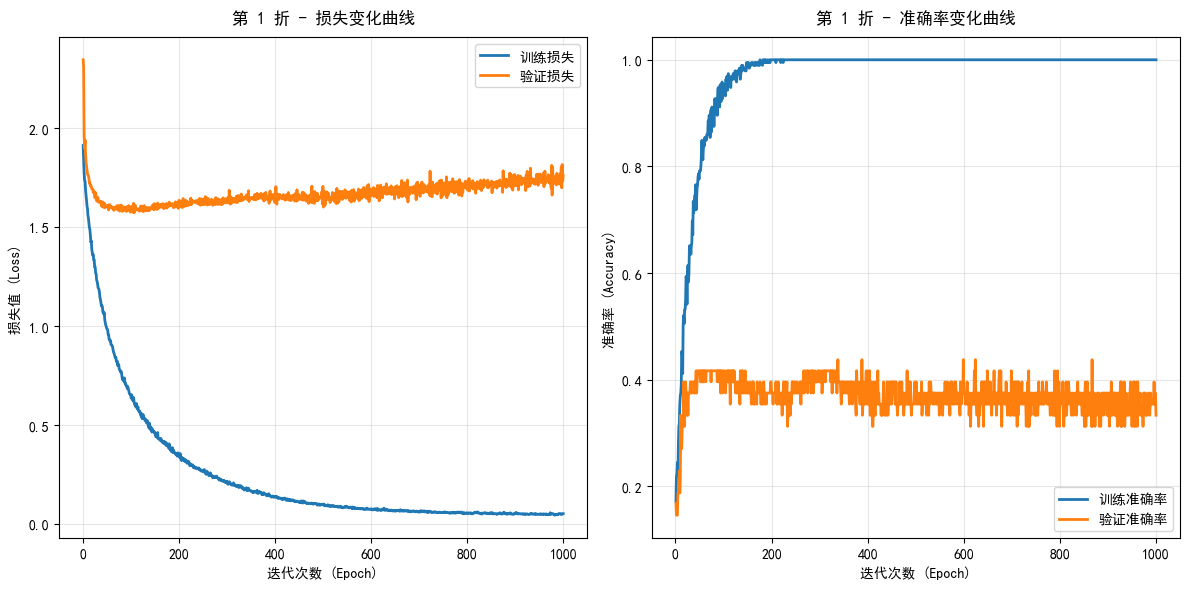


第 2/5 折训练开始
Epoch [1/1000] - 训练损失: 1.9605, 训练准确率: 13.02%
Epoch [1/1000] - 验证损失: 2.1248, 验证准确率: 14.58%
Epoch [2/1000] - 训练损失: 1.8826, 训练准确率: 18.23%
Epoch [2/1000] - 验证损失: 2.0165, 验证准确率: 12.50%
Epoch [3/1000] - 训练损失: 1.8370, 训练准确率: 21.35%
Epoch [3/1000] - 验证损失: 1.8478, 验证准确率: 25.00%
Epoch [4/1000] - 训练损失: 1.7892, 训练准确率: 23.44%
Epoch [4/1000] - 验证损失: 1.8585, 验证准确率: 16.67%
Epoch [5/1000] - 训练损失: 1.7716, 训练准确率: 24.48%
Epoch [5/1000] - 验证损失: 1.9158, 验证准确率: 20.83%
Epoch [6/1000] - 训练损失: 1.7421, 训练准确率: 25.00%
Epoch [6/1000] - 验证损失: 1.8564, 验证准确率: 16.67%
Epoch [7/1000] - 训练损失: 1.7027, 训练准确率: 23.96%
Epoch [7/1000] - 验证损失: 1.8085, 验证准确率: 16.67%
Epoch [8/1000] - 训练损失: 1.6765, 训练准确率: 28.12%
Epoch [8/1000] - 验证损失: 1.7914, 验证准确率: 16.67%
Epoch [9/1000] - 训练损失: 1.6473, 训练准确率: 31.25%
Epoch [9/1000] - 验证损失: 1.7754, 验证准确率: 20.83%
Epoch [10/1000] - 训练损失: 1.6228, 训练准确率: 33.85%
Epoch [10/1000] - 验证损失: 1.7858, 验证准确率: 16.67%
Epoch [11/1000] - 训练损失: 1.6051, 训练准确率: 35.42%
Epoch [11/1000] - 验证损失: 1.7574, 验证准确率: 

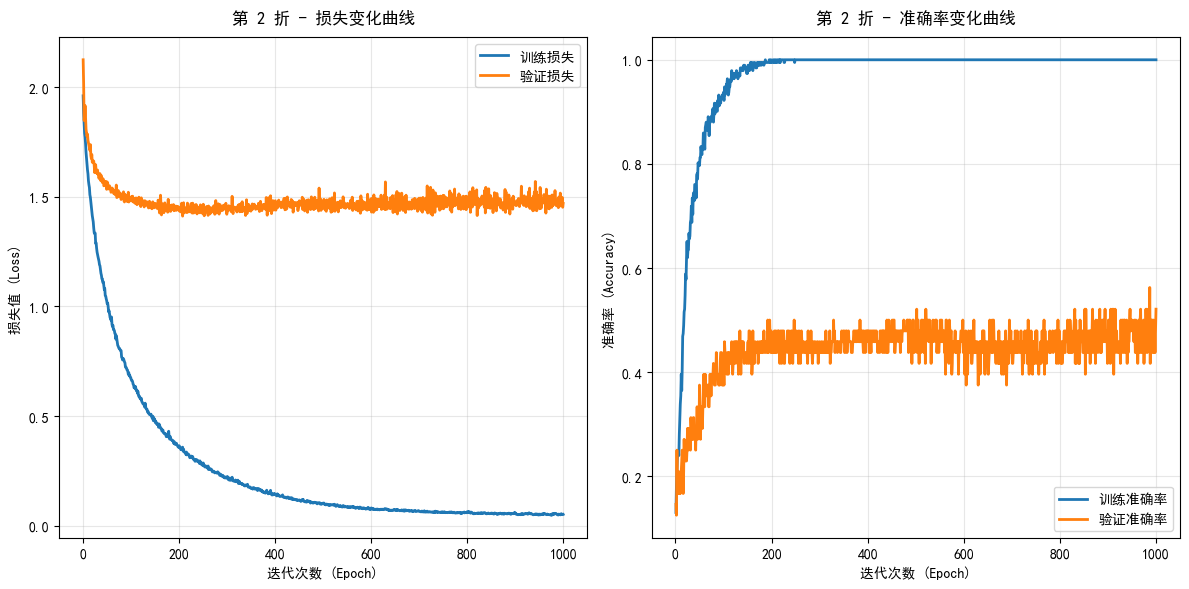


第 3/5 折训练开始
Epoch [1/1000] - 训练损失: 1.9459, 训练准确率: 19.79%
Epoch [1/1000] - 验证损失: 2.0131, 验证准确率: 16.67%
Epoch [2/1000] - 训练损失: 1.8323, 训练准确率: 24.48%
Epoch [2/1000] - 验证损失: 2.0959, 验证准确率: 10.42%
Epoch [3/1000] - 训练损失: 1.8154, 训练准确率: 21.88%
Epoch [3/1000] - 验证损失: 1.9892, 验证准确率: 12.50%
Epoch [4/1000] - 训练损失: 1.7492, 训练准确率: 27.08%
Epoch [4/1000] - 验证损失: 1.8818, 验证准确率: 20.83%
Epoch [5/1000] - 训练损失: 1.7318, 训练准确率: 28.12%
Epoch [5/1000] - 验证损失: 1.8511, 验证准确率: 22.92%
Epoch [6/1000] - 训练损失: 1.6914, 训练准确率: 29.17%
Epoch [6/1000] - 验证损失: 1.8409, 验证准确率: 12.50%
Epoch [7/1000] - 训练损失: 1.6599, 训练准确率: 31.77%
Epoch [7/1000] - 验证损失: 1.8023, 验证准确率: 22.92%
Epoch [8/1000] - 训练损失: 1.6364, 训练准确率: 32.29%
Epoch [8/1000] - 验证损失: 1.8210, 验证准确率: 25.00%
Epoch [9/1000] - 训练损失: 1.6230, 训练准确率: 32.81%
Epoch [9/1000] - 验证损失: 1.7866, 验证准确率: 25.00%
Epoch [10/1000] - 训练损失: 1.5915, 训练准确率: 36.98%
Epoch [10/1000] - 验证损失: 1.7661, 验证准确率: 25.00%
Epoch [11/1000] - 训练损失: 1.5532, 训练准确率: 38.02%
Epoch [11/1000] - 验证损失: 1.7738, 验证准确率: 

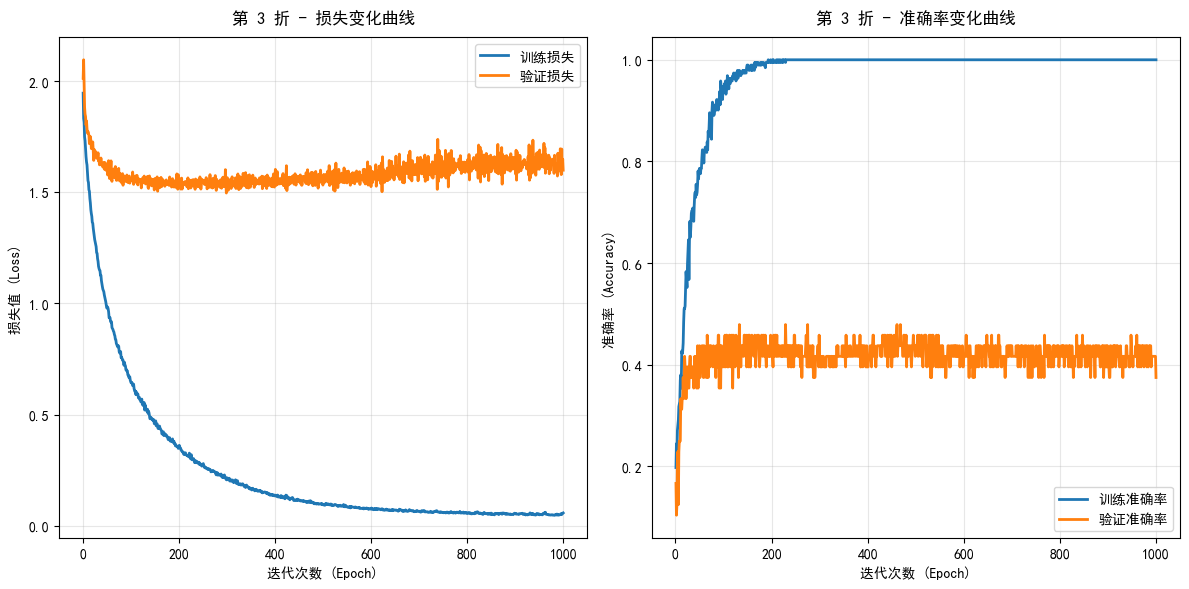


第 4/5 折训练开始
Epoch [1/1000] - 训练损失: 1.9516, 训练准确率: 18.23%
Epoch [1/1000] - 验证损失: 2.0716, 验证准确率: 10.42%
Epoch [2/1000] - 训练损失: 1.7916, 训练准确率: 22.40%
Epoch [2/1000] - 验证损失: 2.4310, 验证准确率: 14.58%
Epoch [3/1000] - 训练损失: 1.7986, 训练准确率: 21.35%
Epoch [3/1000] - 验证损失: 2.1825, 验证准确率: 14.58%
Epoch [4/1000] - 训练损失: 1.7399, 训练准确率: 24.48%
Epoch [4/1000] - 验证损失: 1.9461, 验证准确率: 16.67%
Epoch [5/1000] - 训练损失: 1.7027, 训练准确率: 32.29%
Epoch [5/1000] - 验证损失: 1.8641, 验证准确率: 16.67%
Epoch [6/1000] - 训练损失: 1.6686, 训练准确率: 33.85%
Epoch [6/1000] - 验证损失: 1.8409, 验证准确率: 18.75%
Epoch [7/1000] - 训练损失: 1.6335, 训练准确率: 38.02%
Epoch [7/1000] - 验证损失: 1.8363, 验证准确率: 20.83%
Epoch [8/1000] - 训练损失: 1.6164, 训练准确率: 39.06%
Epoch [8/1000] - 验证损失: 1.8346, 验证准确率: 20.83%
Epoch [9/1000] - 训练损失: 1.5833, 训练准确率: 38.02%
Epoch [9/1000] - 验证损失: 1.7789, 验证准确率: 22.92%
Epoch [10/1000] - 训练损失: 1.5533, 训练准确率: 43.23%
Epoch [10/1000] - 验证损失: 1.7745, 验证准确率: 22.92%
Epoch [11/1000] - 训练损失: 1.5379, 训练准确率: 42.71%
Epoch [11/1000] - 验证损失: 1.7877, 验证准确率: 

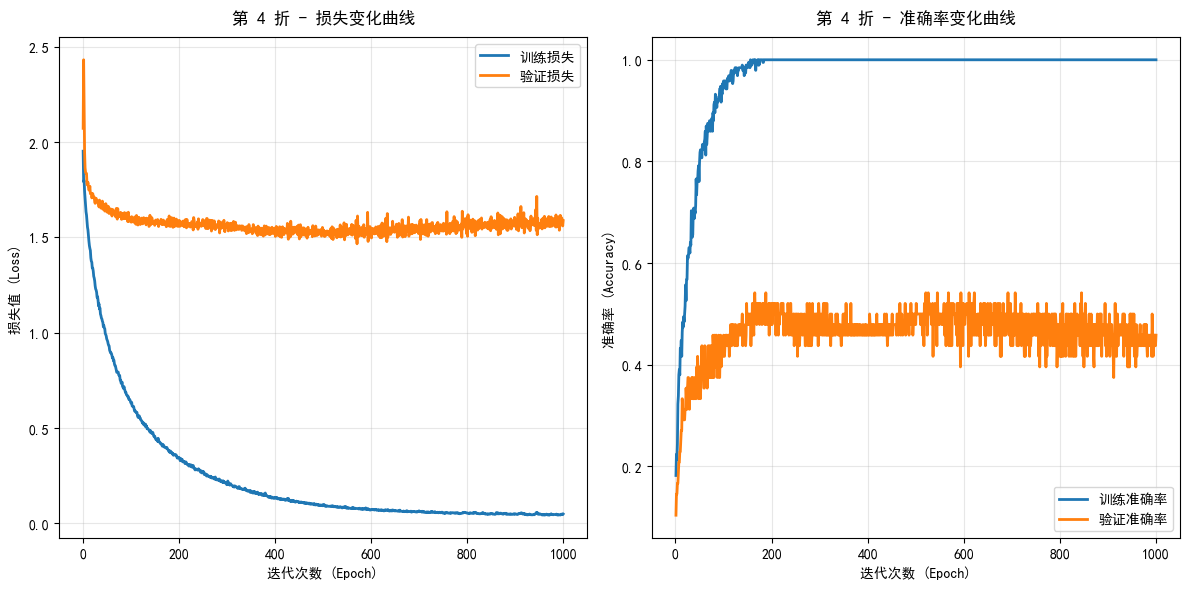


第 5/5 折训练开始
Epoch [1/1000] - 训练损失: 1.8859, 训练准确率: 20.31%
Epoch [1/1000] - 验证损失: 2.0547, 验证准确率: 18.75%
Epoch [2/1000] - 训练损失: 1.8196, 训练准确率: 20.31%
Epoch [2/1000] - 验证损失: 2.0640, 验证准确率: 10.42%
Epoch [3/1000] - 训练损失: 1.7952, 训练准确率: 20.31%
Epoch [3/1000] - 验证损失: 2.0536, 验证准确率: 6.25%
Epoch [4/1000] - 训练损失: 1.7713, 训练准确率: 24.48%
Epoch [4/1000] - 验证损失: 1.9403, 验证准确率: 10.42%
Epoch [5/1000] - 训练损失: 1.7172, 训练准确率: 29.17%
Epoch [5/1000] - 验证损失: 1.9176, 验证准确率: 12.50%
Epoch [6/1000] - 训练损失: 1.6986, 训练准确率: 28.65%
Epoch [6/1000] - 验证损失: 1.8972, 验证准确率: 10.42%
Epoch [7/1000] - 训练损失: 1.6584, 训练准确率: 32.81%
Epoch [7/1000] - 验证损失: 1.8229, 验证准确率: 14.58%
Epoch [8/1000] - 训练损失: 1.6351, 训练准确率: 36.98%
Epoch [8/1000] - 验证损失: 1.8305, 验证准确率: 16.67%
Epoch [9/1000] - 训练损失: 1.6056, 训练准确率: 38.02%
Epoch [9/1000] - 验证损失: 1.8042, 验证准确率: 20.83%
Epoch [10/1000] - 训练损失: 1.5869, 训练准确率: 38.02%
Epoch [10/1000] - 验证损失: 1.8091, 验证准确率: 16.67%
Epoch [11/1000] - 训练损失: 1.5523, 训练准确率: 44.79%
Epoch [11/1000] - 验证损失: 1.7861, 验证准确率: 1

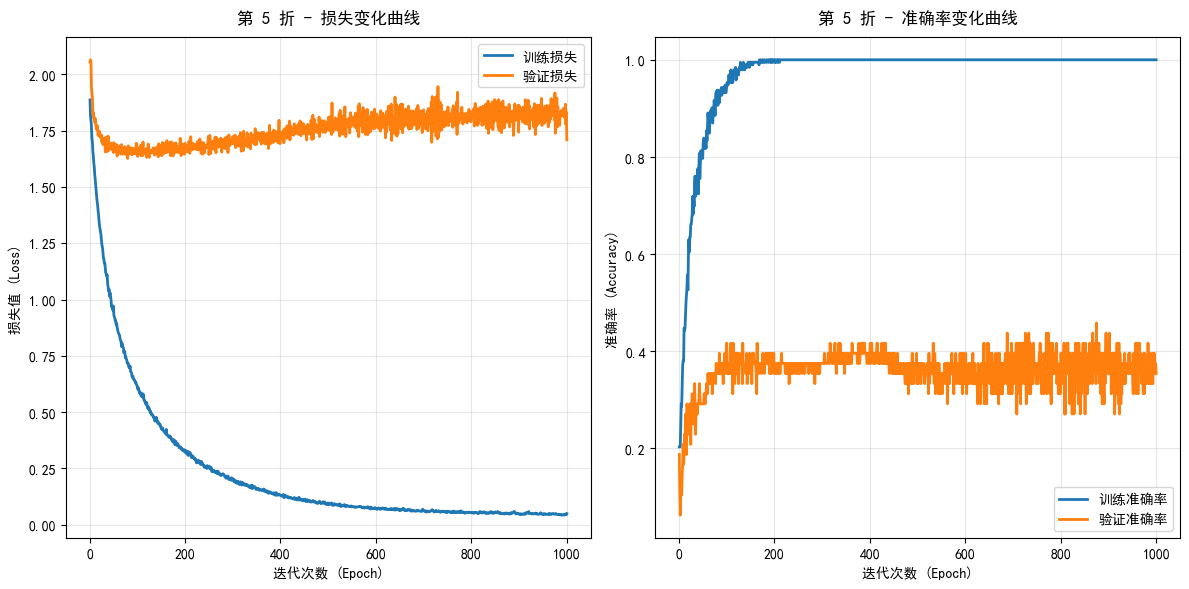


五折交叉验证结果
平均验证准确率: 49.58%
平均验证损失: 1.6059
全局最佳验证准确率: 56.25%
单韵母FBCNet模型已保存为：FBCNet_single_vowel_model.pth


In [20]:

# 1. 初始化单韵母FBCNet模型（关键修改：替换模型类+修正nTime）
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
fbcnet_model = FBCNetSingleVowelModel(
    nChan=32,        # 单韵母数据的通道数（与数据一致，如32导）
    nTime=1000,      # 修正！250Hz×4s=1000时间点（原代码写500，会导致维度不匹配）
    nClass=6,        # 单韵母类别数（6类：a/o/e/i/u/ü，注释修正）
    nBands=10,       # 与单韵母数据的频段数一致（10个频段）
    m=16,            # 每个频段的空间滤波器数量（与原配置一致，可微调）
    temporalLayer='LogVarLayer',  # 时间聚合方式（复用）
    strideFactor=4   # 时间分块步长（1000/4=250块，适配nTime=1000）
).to(device)

# 查看模型结构（输入形状：(1, 32, 1000, 10) → 对应(batch=1, C, T, nBands)，与单韵母数据格式一致）
# 注：若summary报错，需确认输入维度是否匹配模型forward的要求（FBCNet输入为(N,1,C,T,nBands)，summary会自动补batch）
summary(fbcnet_model, input_size=(1, 32, 1000, 10))  # 输入维度：(1, C, T, nBands)


# 2. 训练超参数（与EEGNet一致，无需修改，确保对比公平）
EPOCHS = 1000
BATCH_SIZE = 32  
LEARNING_RATE = 0.0001
N_splits = 5
Weight_decay = 0.1 # 权重衰减（L2正则化，防止过拟合）

# 3. 启动五折交叉验证训练（关键修改：替换为单韵母训练数据集）
trainer = TrainModel()  
trained_fbcnet_model = trainer.train_model(
    model_class=FBCNetSingleVowelModel,  # 替换为单韵母模型类（非原笔画模型）
    dataset=train_dataset,  # 关键！替换为单韵母的训练数据集（非笔画数据集）
    learning_rate=LEARNING_RATE,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    n_splits=N_splits,
    weight_decay=Weight_decay,
    selection_metric='accuracy'  # 按准确率选择最佳模型（合理）
)

# 4. 保存单韵母模型（关键修改：修改文件名，避免与笔画模型混淆）
model_save_path = 'FBCNet_single_vowel_model.pth'  # 明确标注“单韵母”，便于后续调用
torch.save(trained_fbcnet_model.state_dict(), model_save_path)
print(f"单韵母FBCNet模型已保存为：{model_save_path}")

#  评估测试集（session2）的准确率 

/------------------------------/
测试集准确率: 43.75%
/------------------------------/


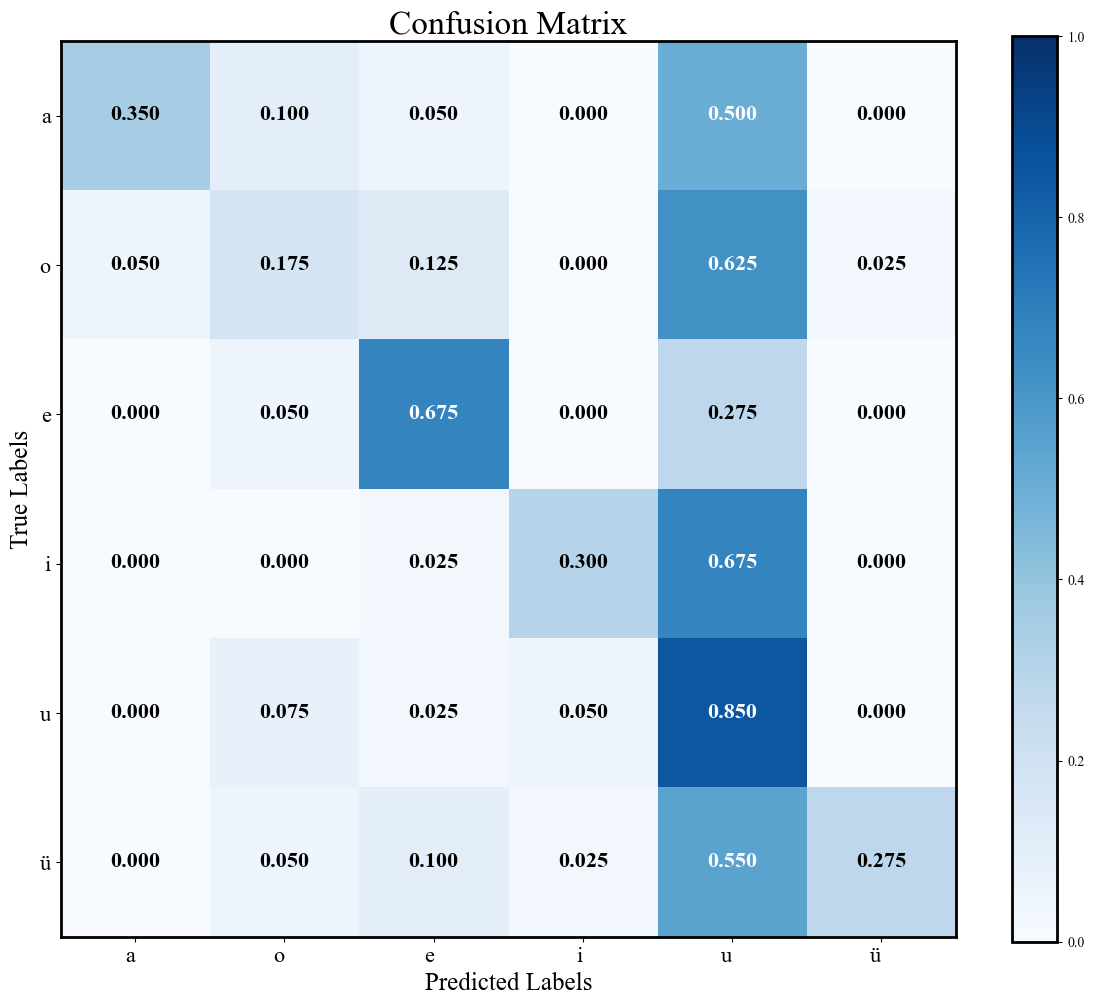

In [14]:
classes_list  = ['a', 'o', 'e', 'i', 'u', 'ü']    # Category labels: Pinyin monophthong names
#classes_list = ['一', '丨', '丿', '㇏', 'ㄥ']
eval_model = EvalModel(trained_fbcnet_model)  
test_accuracy = eval_model.test_model(test_dataset)
eval_model.plot_confusion_matrix(test_dataset, classes_list)